# Day 2 — Probability & Distributions

## Step 1:

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


Pandas, NumPy and Matplotlib libraries imported.

In [35]:
np.random.seed(42)
flips = np.random.randint(0, 2, size=10000)
print(flips)

[0 1 0 ... 1 1 0]


- .seed() used to ensure an identical set of numbers is generated every time the code executes.
- .randint() to specify the domain of numbers to be generated and the size of the array.
- numbers are 0 = Tails, and 1 = Heads

In [36]:
heads = sum(flips)
heads_prpt = heads/len(flips)

print("Number of heads:", heads)
print("Proportion of heads to overall flips:", heads_prpt)

Number of heads: 4987
Proportion of heads to overall flips: 0.4987


Proportion of heads is 0.49 which is almost half the total number of flips!

In [37]:
running_flip_prpt = np.cumsum(flips)/np.arange(1,len(flips)+1)
print(running_flip_prpt)

[0.         0.5        0.33333333 ... 0.49869974 0.49874987 0.4987    ]


- cumsum - cummulative sum of flips so far
- arrange - whiah flip are we in rn
- "running_flip_prpt" produces an array that sums the flips from the first to the current cummulatively and divide it by the current position of the flip(index)

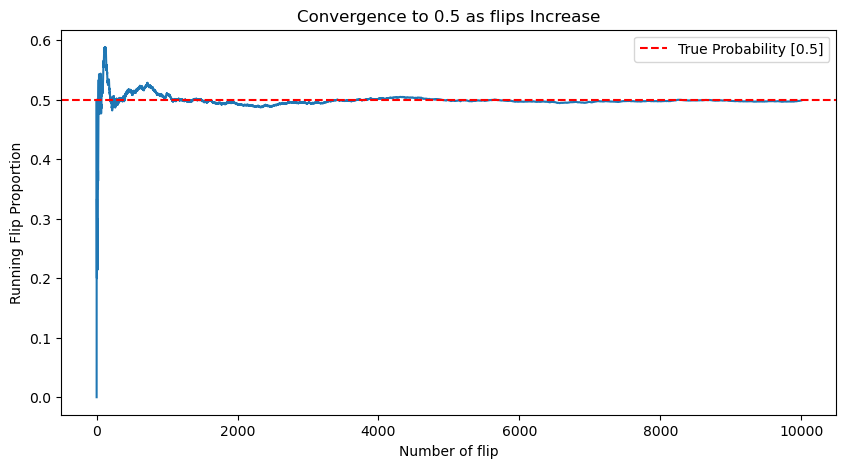

In [41]:
plt.figure(figsize= (10,5))
plt.plot(running_flip_prpt)
plt.axhline(y=0.5, color='red', linestyle='--',label="True Probability [0.5]")
plt.xlabel("Number of flip")
plt.ylabel("Running Flip Proportion")
plt.title("Convergence to 0.5 as flips Increase")
plt.legend()
plt.show()


## Step 2:

In [60]:
np.random.seed(42)
samples = np.random.normal(loc=0, scale=1, size=10000)
print(samples)

[-1.26405266  1.52790535 -0.97071094 ...  1.20547412  0.65714621
 -0.21678298]


- .normal() to produce a symmetric distribution
- mean = 0
- standard deviation = 1

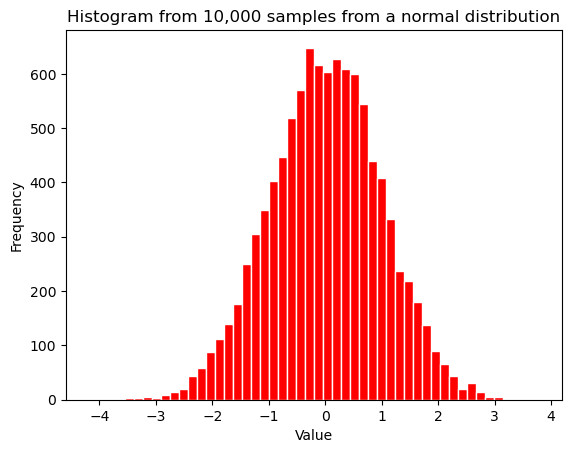

In [69]:
plt.hist(samples, bins = 50,color='red', edgecolor='white')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram from 10,000 samples from a normal distribution")
plt.show()

The histogram shows even distribution of 10000 samples around 0 forming a bel shape.

## Step 3:

- Given a deck of cards, and a face card being selected. What is the probability of drawing a king card?
- P(King|Face cards) = ?
- #king crads = 4
- #Face cards = 12
- P(King|Face cards)=4/12 = 1/3
- There is a 33.3% probability of drawing a king card from a collection of face cards.


### Conditional Probability with Solitare Deck

In [79]:
np.random.seed(42)
ranks = ['A','2','3','4','5','6','7','8','9','10','J','Q','K'] * 4
deck = np.array(ranks)
print(deck)
## the calculatioin is done 10000 times to converge to the true probability (Law of Large Numbers)
n_times=10000
draws=np.random.choice(deck,size=n_times, replace=True)
face= np.isin(draws, ['J','Q','K'])
king= np.isin(draws, ['K'])
print(np.unique(draws))

probB = face.sum() / n_times
prob_A_andB = (face & king).sum() / n_times
prob_A_given_B = prob_A_andB / probB 

print(f"P(B) = {probB:.4f}")
print(f"P(A and B) = {prob_A_andB:.4f}")
print(f"P(A|B) = {prob_A_given_B:.4f}")

['A' '2' '3' '4' '5' '6' '7' '8' '9' '10' 'J' 'Q' 'K' 'A' '2' '3' '4' '5'
 '6' '7' '8' '9' '10' 'J' 'Q' 'K' 'A' '2' '3' '4' '5' '6' '7' '8' '9' '10'
 'J' 'Q' 'K' 'A' '2' '3' '4' '5' '6' '7' '8' '9' '10' 'J' 'Q' 'K']
['10' '2' '3' '4' '5' '6' '7' '8' '9' 'A' 'J' 'K' 'Q']
P(B) = 0.2342
P(A and B) = 0.0805
P(A|B) = 0.3437


- 10000 random card draws executed for verification
- The result is nearly 0.33 which verifies the by-hand calculation.
- The value could be brought closer to the 0.33 by increasing the number of trials according to Law of Large Numbers.